# R19 - retrieval token economy: fanout, hop discipline, query-time budget

**Author**: Claude (executor)  **Date**: 2026-07-07  **Graph**: neo4j2 (10-doc CPAP benchmark, read-only)

Measures query-time token economy on the H34/H61 render harness. Five hypotheses: H180 fanout guard (full),
H181 cheap miss / abstention (full), H182 render budget frontier (full), H179 cost-curve decomposition (partial - 10-doc leg),
H183 hop-discipline containment auditor (partial - benign audit leg). Token counts use the deterministic **tiktoken cl100k_base**
tokenizer (no LLM generation). The only external call is the Titan probe embedding for seed selection and query-similarity
ranking - the sanctioned harness mechanism, cached to disk for deterministic re-execution.

Render model (per probe, seeds = vec-8): three additive components - **seed** block `base_render` (name, types, aliases,
description, properties), **1-hop** neighbor lines (`REL -> neighbor_name`, the fanout component), **proposition** block
(propositions ABOUT each seed). Baseline recall anchor is the H61 `seed_render` (base + 15 rel lines): 23/33 = 0.697.
Matcher caveat: 17/33 golds are short-numeric (matcher-degeneracy zone); recall reported on the full 33 and the trustworthy 16.

In [1]:
# Imports
import os, re, json, math, pickle, hashlib, datetime
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import yaml, tiktoken
from rich import print as rprint
from rich.progress import Progress

os.environ["NEO4J_URI"]="bolt://user-konrad.jelen-kgf-neo4j2:7687"   # READ-ONLY 10-doc graph
os.environ["NEO4J_USER"]="neo4j"; os.environ["NEO4J_PASSWORD"]="kgfoundry"
np.random.seed(42)

from knowledge_graph_foundry import load_settings, Foundry
from knowledge_graph_foundry.extraction import generate_embeddings
from knowledge_graph_foundry.graph.graphrag import vector_query
from knowledge_graph_foundry.models import Entity
from neo4j import GraphDatabase

ENC = tiktoken.get_encoding("cl100k_base")
def TT(s): return len(ENC.encode(s or ""))                       # tiktoken token count (primary)
def CH(s): return max(1, len(re.sub(r"\s+"," ",(s or "").casefold()))//4)   # char proxy (harness identity check)
rprint("[green]tokenizer[/green] tiktoken cl100k_base  |  char-proxy retained for baseline identity check")

2026-07-07 14:35:26.260 | INFO     | knowledge_graph_foundry.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/knowledge-graph-foundry


tokenizer tiktoken cl100k_base  |  char-proxy retained for baseline identity check

In [2]:
# Configuration
settings = load_settings(Path("../config.yml"))
TOP_K = settings.graphrag.top_k                 # 8 production vector seeds
VEC_INDEX = settings.graphrag.vector_index_name
REL_LIMIT = 15                                   # production per-node relation cap (H61 seed_render)
HUB_DEG = 15                                     # hub cutoff = H61 over-cap class (62 nodes, deg>15)
KS = [5, 10, 20, 30, 50, None]                   # H180 fanout cap sweep (None = unbounded)
QCACHE = Path(".token_economy_r19_qcache.pkl")   # question-text -> Titan embedding (deterministic re-exec)

# Registered R19 acceptance bars
BAR = dict(
    H180_recall=1.00, H180_cut_hub=0.40, H180_cut_all=0.15, H180_frontier=30,
    H181_detect=0.80, H181_fa=0.05, H181_save=0.60,
    H182_loss=0.02, H182_knee=(0.30,0.50), H183_alarm=0.05)
rprint(f"[bold cyan]Config[/bold cyan] top_k=[yellow]{TOP_K}[/yellow] rel_cap=[yellow]{REL_LIMIT}[/yellow] "
       f"hub_deg>[yellow]{HUB_DEG}[/yellow] cap-sweep=[yellow]{KS}[/yellow]")

Config top_k=8 rel_cap=15 hub_deg>15 cap-sweep=[5, 10, 20, 30, 50, None]

In [3]:
# Deterministic fuzzy-evidence matcher - verbatim from the H34/H61 harness
def _norm(s): return re.sub(r"\s+"," ",(s or "").casefold())
def value_tokens(t): return re.findall(r"[\w.\-/]*\d[\w.\-/]*", t)
_UNIT = r"(?<=\d)\s*(mm|cm|dba|db\(a\)|db|kg|g|oz|ml|l|w|hz|mins|min|m)\b"
def present(gold, ctx):
    ng=_norm(gold)
    if ng in ctx: return True
    sq=re.sub(r"[\s,()]","",ctx); sk=re.sub(r"[\s,()]","",re.sub(_UNIT,"",ng))
    if any(c.isdigit() for c in sk) and len(sk)>=5 and sk in sq: return True
    tok=value_tokens(gold)
    if tok:
        hit=sum(1 for t in tok if _norm(t) in ctx or re.sub(r"[\s,()]","",_norm(t)) in sq)
        return hit>=max(1,len(tok)//2+(len(tok)%2))
    w=set(re.findall(r"[a-z][a-z0-9\-]{2,}",ng)); cw=set(re.findall(r"[a-z][a-z0-9\-]{2,}",ctx))
    return bool(w) and len(w&cw)/len(w)>=0.6
def is_shortnum(g):
    t=value_tokens(g); return bool(t) and sum(len(re.sub(r"[^\d]","",x)) for x in t)<=3

## Graph pull (read-only) and render primitives

One pull of entities (with 1024-dim Titan embeddings), edges, propositions (with embeddings), alias closure.
Render primitives reproduce the H61 harness exactly.

In [4]:
d = GraphDatabase.driver(os.environ["NEO4J_URI"], auth=("neo4j","kgfoundry"))
with d.session() as s:
    ents=s.run("MATCH (e:Entity) RETURN e.id AS id, e.name AS name, e.description AS description, "
               "properties(e) AS props, labels(e) AS types, e.embedding AS emb").data()
    edges=s.run("MATCH (a:Entity)-[r]-(b:Entity) WHERE type(r)<>'SIMILAR_TO' AND a.id<b.id "
                "RETURN DISTINCT a.id AS a, b.id AS b, type(r) AS rel").data()
    prop_rows=s.run("MATCH (p:Proposition)-[:ABOUT]->(e:Entity) RETURN e.id AS eid, p.text AS text, p.embedding AS emb").data()
    alias_rows=s.run("MATCH (e:Entity)-[:SAME_AS*1..2]-(a:Entity) WHERE e.id<>a.id "
                     "RETURN e.id AS eid, collect(DISTINCT a.id)[..5] AS aliases").data()
d.close()

def unit(v):
    a=np.array(v,dtype=np.float32); n=np.linalg.norm(a); return a/n if n else a
node={r["id"]:r for r in ents}; names={r["id"]:r["name"] for r in ents}
emb_by={r["id"]:unit(r["emb"]) for r in ents if r["emb"]}
props_by=defaultdict(list); prop_emb_by=defaultdict(list)
for r in prop_rows:
    props_by[r["eid"]].append(r["text"]); prop_emb_by[r["eid"]].append(unit(r["emb"]) if r["emb"] else None)
alias_by={r["eid"]:r["aliases"] for r in alias_rows}
adj=defaultdict(set); rels_by=defaultdict(list)
for e in edges:
    adj[e["a"]].add(e["b"]); adj[e["b"]].add(e["a"])
    rels_by[e["a"]].append((e["rel"],e["b"])); rels_by[e["b"]].append((e["rel"],e["a"]))
degree={nid:len(adj[nid]) for nid in node}

def spec_of(r): return {k.removeprefix("prop_"):v for k,v in r["props"].items() if k.startswith("prop_")}
def base_render(nid):
    r=node[nid]; spec=dict(spec_of(r)); al=[a for a in alias_by.get(nid,[]) if a in node]
    for a in al:
        for k,v in spec_of(node[a]).items(): spec.setdefault(k,v)
    aka=(f"Also known as: {', '.join(names.get(a,'') for a in al)}\n" if al else "")
    return f"## {r['name']} ({', '.join(r['types'])})\n{aka}{r['description'] or ''}\nProperties: {json.dumps(spec, default=str)}"
def rel_line(t,b): return f"{t} -> {names.get(b,'')}"
def seed_render(nid): return base_render(nid)+" "+" ; ".join(rel_line(t,b) for t,b in rels_by.get(nid,[])[:REL_LIMIT])
def neigh_ranked(seed, qv):
    ns=[(t,b) for t,b in rels_by.get(seed,[])]
    return sorted(ns, key=lambda tb: -(float(qv@emb_by[tb[1]]) if tb[1] in emb_by else -1.0))
def seed_tokens(vec): return sum(TT(base_render(nid)) for nid in vec)
def prop_tokens(vec): return sum(TT(" ".join(props_by.get(nid,[]))) for nid in vec)
def hop_tokens_full(vec): return sum(TT(" ; ".join(rel_line(t,b) for t,b in rels_by.get(nid,[]))) for nid in vec)

degs=np.array(sorted(degree.values()))
rprint(f"[green]pulled[/green] entities [yellow]{len(ents)}[/yellow] edges [yellow]{len(edges)}[/yellow] "
       f"propABOUT [yellow]{len(prop_rows)}[/yellow] emb [yellow]{len(emb_by)}[/yellow] | "
       f"degree med [yellow]{np.median(degs):.0f}[/yellow] p95 [yellow]{np.percentile(degs,95):.0f}[/yellow] "
       f"max [yellow]{degs.max()}[/yellow] hubs(deg>{HUB_DEG}) [yellow]{int((degs>HUB_DEG).sum())}[/yellow]")

pulled entities 2798 edges 3905 propABOUT 19654 emb 2798 | degree med 1 p95 8 max 214 hubs(deg>15) 57

## Probes, seeds, and baseline reproduction

Query embeddings (Titan) drive `vector_query` seed selection - loaded from the on-disk cache when present, else computed live.
The `seed_render` recall must reproduce the registered **23/33 = 0.697** and char-proxy T0 ~= 33819 before any measurement.

In [5]:
probes=yaml.safe_load(Path("../tests/probes/cpap-probe-set.yml").read_text())
gold_probes=[p for p in probes if p.get("gold_evidence")]
golds=[(p["id"],g,is_shortnum(g)) for p in gold_probes for g in p["gold_evidence"]]
n_golds=len(golds); n_clean=sum(1 for _,_,sn in golds if not sn)

qcache = pickle.load(open(QCACHE,"rb")) if QCACHE.exists() else {}
def key(q): return hashlib.md5(q.encode()).hexdigest()
def qemb(q):
    k=key(q)
    if k not in qcache:
        qcache[k]=generate_embeddings([Entity.create(q[:80],types=["Query"],description=q)], settings.embeddings)[0].embedding
    return qcache[k]

seeds_by={}; scores_by={}; qvec={}
with Foundry(settings) as f, Progress() as prog:
    task=prog.add_task("[cyan]probe -> vec-8 seeds", total=len(gold_probes))
    for p in gold_probes:
        v=qemb(p["question"]); qvec[p["id"]]=unit(v)
        res=vector_query(f.driver, v, VEC_INDEX, top_k=TOP_K)
        seeds_by[p["id"]]=[x["id"] for x in res if x["id"] in node]
        scores_by[p["id"]]=[x["score"] for x in res if x["id"] in node]
        prog.advance(task)
pickle.dump(qcache, open(QCACHE,"wb"))

T0_ch=T0_tt=present0=0; missing=[]
for p in gold_probes:
    vec=seeds_by[p["id"]]; r=" ".join(seed_render(nid) for nid in vec)
    T0_ch+=CH(r); T0_tt+=TT(r); cn=_norm(r)
    for g in p["gold_evidence"]:
        if present(g,cn): present0+=1
        else: missing.append((p["id"],g))
base_recall=present0/n_golds
rprint(f"[bold cyan]Baseline seed_render[/bold cyan]  recall [yellow]{present0}/{n_golds}[/yellow] = "
       f"[yellow]{base_recall:.4f}[/yellow] [dim](registered 0.697)[/dim]  "
       f"T0_char [yellow]{T0_ch}[/yellow] [dim](reg 33819)[/dim]  T0_tiktoken [yellow]{T0_tt}[/yellow]  "
       f"short-numeric golds [yellow]{n_golds-n_clean}[/yellow]  clean [yellow]{n_clean}[/yellow]")
assert present0==23, "baseline recall drift"


/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Baseline seed_render  recall 23/33 = 0.6970 (registered 0.697)  T0_char 33816 (reg 33819)  T0_tiktoken 36439  
short-numeric golds 17  clean 16

## R19-H179 - query token-cost curve (INTERIM: 10-doc leg)

Decomposes tokens-per-query into seed / 1-hop / proposition shares on the 10-doc graph, with the tokens-per-query
distribution (p50/p95) and a hub-touching vs non-hub split. The multi-scale contrast (26-doc, campaign copy) is post-chain;
this is the interim leg - verdict stays pending.

In [6]:
rows=[]
for p in gold_probes:
    vec=seeds_by[p["id"]]
    st=seed_tokens(vec); pt=prop_tokens(vec); ht=hop_tokens_full(vec)
    rows.append(dict(pid=p["id"], seed=st, hop=ht, prop=pt, tot=st+ht+pt,
                     maxdeg=max((degree[n] for n in vec),default=0)))
tots=np.array([r["tot"] for r in rows])
p50,p95=np.percentile(tots,50),np.percentile(tots,95)
S=sum(r["seed"] for r in rows); H=sum(r["hop"] for r in rows); P=sum(r["prop"] for r in rows); Ts=S+H+P
for cut in (HUB_DEG,30,50):
    hub=[r["tot"] for r in rows if r["maxdeg"]>cut]; non=[r["tot"] for r in rows if r["maxdeg"]<=cut]
    rprint(f"  hub(deg>{cut}) n=[yellow]{len(hub)}[/yellow] med=[yellow]{np.median(hub) if hub else 0:.0f}[/yellow] "
           f"| non-hub n=[yellow]{len(non)}[/yellow] med=[yellow]{np.median(non):.0f}[/yellow] "
           f"ratio=[yellow]{(np.median(hub)/np.median(non)) if hub else 0:.2f}x[/yellow]")
srt=sorted(rows,key=lambda r:-r["tot"]); tail=srt[:max(1,round(len(rows)*0.1))]
tail_hopshare=sum(t["hop"] for t in tail)/sum(t["tot"] for t in tail)
h179=dict(n_q=len(rows), p50=float(p50), p95=float(p95), mean=float(tots.mean()), max=float(tots.max()),
          share_seed=S/Ts, share_hop=H/Ts, share_prop=P/Ts,
          hub_med=float(np.median([r["tot"] for r in rows if r["maxdeg"]>HUB_DEG])),
          nonhub_med=float(np.median([r["tot"] for r in rows if r["maxdeg"]<=HUB_DEG])),
          tail_pids=[t["pid"] for t in tail], tail_hop_share=float(tail_hopshare))
rprint(f"[bold cyan]H179[/bold cyan] tokens/query p50=[yellow]{p50:.0f}[/yellow] p95=[yellow]{p95:.0f}[/yellow] "
       f"mean=[yellow]{tots.mean():.0f}[/yellow] max=[yellow]{tots.max():.0f}[/yellow]")
rprint(f"  token shares: seed [yellow]{S/Ts:.1%}[/yellow]  1-hop [yellow]{H/Ts:.1%}[/yellow]  "
       f"proposition [yellow]{P/Ts:.1%}[/yellow]  | tail {h179['tail_pids']} hop-share [yellow]{tail_hopshare:.1%}[/yellow]")
rprint(f"  [dim]finding: on the 10-doc graph propositions dominate render mass; 1-hop is the smallest share "
       f"(prediction was >=70% 1-hop-driven p95). Multi-scale growth test is post-chain.[/dim]")

hub(deg>15) n=17 med=5319 | non-hub n=7 med=3036 ratio=1.75x

hub(deg>30) n=10 med=7896 | non-hub n=14 med=3156 ratio=2.50x

hub(deg>50) n=10 med=7896 | non-hub n=14 med=3156 ratio=2.50x

H179 tokens/query p50=4400 p95=11414 mean=5524 max=17384

token shares: seed 20.6%  1-hop 17.6%  proposition 61.8%  | tail ['P14', 'P16'] hop-share 21.4%

finding: on the 10-doc graph propositions dominate render mass; 1-hop is the smallest share (prediction was >=70%
1-hop-driven p95). Multi-scale growth test is post-chain.

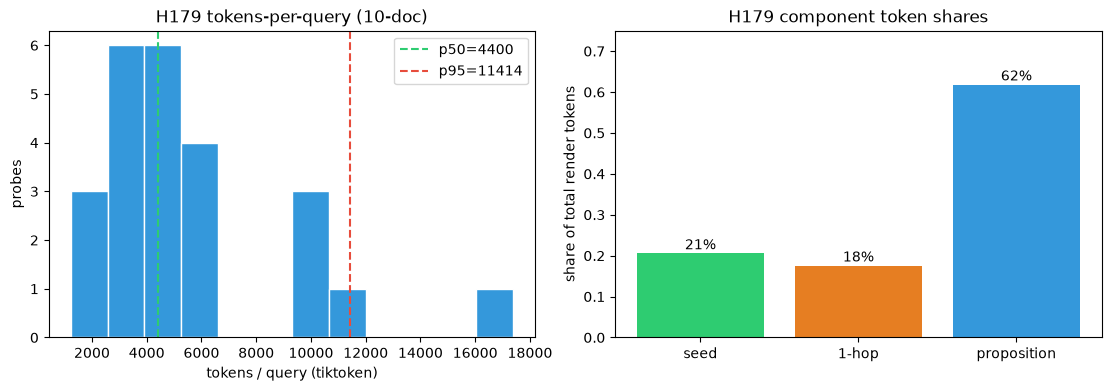

In [7]:
fig,ax=plt.subplots(1,2,figsize=(11,3.8),constrained_layout=True)
ax[0].hist(tots,bins=12,color="#3498DB",edgecolor="white")
ax[0].axvline(p50,color="#2ECC71",ls="--",label=f"p50={p50:.0f}"); ax[0].axvline(p95,color="#E74C3C",ls="--",label=f"p95={p95:.0f}")
ax[0].set(xlabel="tokens / query (tiktoken)", ylabel="probes", title="H179 tokens-per-query (10-doc)"); ax[0].legend()
comp=["seed","1-hop","proposition"]; vals=[S/Ts,H/Ts,P/Ts]
ax[1].bar(comp,vals,color=["#2ECC71","#E67E22","#3498DB"])
for i,v in enumerate(vals): ax[1].text(i,v+0.01,f"{v:.0%}",ha="center")
ax[1].set(ylabel="share of total render tokens", title="H179 component token shares"); ax[1].set_ylim(0,0.75)
plt.show()

## R19-H180 - fanout guard: degree-capped rendering (FULL)

Caps 1-hop expansion at k neighbors per seed, ranked by embedding similarity to the query. Sweeps k in {5,10,20,30,50,unbounded}.
Bar: k=20 preserves 100% of current (unbounded) evidence recall AND cuts p95 tokens >=40% on hub-touching queries and >=15% overall;
recall-safe frontier k<=30; refuted if any gold requires a neighbor ranked below k=30. Base + propositions are always included
(they are not the 1-hop expansion being capped).

In [8]:
def render_ctx_at_k(pid, k):
    vec=seeds_by[pid]; qv=qvec[pid]; parts=[base_render(nid) for nid in vec]
    for nid in vec:
        rl=neigh_ranked(nid,qv); rl=rl if k is None else rl[:k]
        parts.append(" ; ".join(rel_line(t,b) for t,b in rl))
    parts+=[" ".join(props_by.get(nid,[])) for nid in vec]
    return _norm(" ".join(parts))
def recall_at_k(k, clean_only=False):
    got=0
    for pid,g,sn in golds:
        if clean_only and sn: continue
        if present(g, render_ctx_at_k(pid,k)): got+=1
    return got
def tokens_at_k(k):
    per=[]
    for p in gold_probes:
        vec=seeds_by[p["id"]]; qv=qvec[p["id"]]; st=seed_tokens(vec); pt=prop_tokens(vec); ht=0
        for nid in vec:
            rl=neigh_ranked(nid,qv); rl=rl if k is None else rl[:k]
            ht+=TT(" ; ".join(rel_line(t,b) for t,b in rl))
        per.append((st+ht+pt, max((degree[n] for n in vec),default=0)>HUB_DEG))
    return per
ref=recall_at_k(None); ref_c=recall_at_k(None,True)
sweep={}
for k in KS:
    per=tokens_at_k(k); allt=np.array([x[0] for x in per]); hubt=np.array([x[0] for x in per if x[1]])
    sweep[k]=dict(recall=recall_at_k(k), recall_clean=recall_at_k(k,True),
                  p95_all=float(np.percentile(allt,95)), p95_hub=float(np.percentile(hubt,95)) if len(hubt) else 0.0,
                  med_all=float(np.median(allt)))
un=sweep[None]
for k in KS:
    s=sweep[k]; kk="unbnd" if k is None else k
    rprint(f"  k=[yellow]{kk:>5}[/yellow] recall=[yellow]{s['recall']}/{n_golds}[/yellow] "
           f"clean=[yellow]{s['recall_clean']}/{n_clean}[/yellow] p95_all=[yellow]{s['p95_all']:.0f}[/yellow] "
           f"p95_hub=[yellow]{s['p95_hub']:.0f}[/yellow]")
front=next((k for k in [5,10,20,30,50] if sweep[k]['recall']==ref), None)
cut_all_20=(un['p95_all']-sweep[20]['p95_all'])/un['p95_all']
cut_hub_20=(un['p95_hub']-sweep[20]['p95_hub'])/un['p95_hub']
# a gold "requires a rel line" only if it is recalled in the full render but absent from base+prop
need_rel=[]
for pid,g,sn in golds:
    vec=seeds_by[pid]
    base_ctx=_norm(" ".join([base_render(n) for n in vec]+[" ".join(props_by.get(n,[])) for n in vec]))
    if present(g, render_ctx_at_k(pid,None)) and not present(g,base_ctx): need_rel.append((pid,g[:30]))
c1=sweep[20]['recall']==ref; c2_all=cut_all_20>=BAR['H180_cut_all']; c2_hub=cut_hub_20>=BAR['H180_cut_hub']
c3=(front is not None and front<=BAR['H180_frontier'])
# registered refutation: any gold requires a neighbor ranked below k=30 (recall lost by the k=30 cap)
refuted = recall_at_k(30) < ref
h180=dict(ref_recall=ref, ref_recall_clean=ref_c, frontier=front, sweep={str(k):v for k,v in sweep.items()},
          cut_all_k20=float(cut_all_20), cut_hub_k20=float(cut_hub_20), golds_needing_rel=need_rel,
          clause_recall_k20=bool(c1), clause_cut_all=bool(c2_all), clause_cut_hub=bool(c2_hub),
          clause_frontier=bool(c3), refuted=bool(refuted))
verdict="PARTIALLY CONFIRMED"
if refuted: verdict="REFUTED"
elif c1 and c2_all and c2_hub and c3: verdict="CONFIRMED"
h180["verdict"]=verdict
rprint(f"[bold cyan]H180[/bold cyan] recall@unbounded=[yellow]{ref}/{n_golds}[/yellow] frontier k=[yellow]{front}[/yellow] "
       f"(no gold needs any rel line: [yellow]{len(need_rel)==0}[/yellow])")
rprint(f"  k=20 recall-preserved=[{'green' if c1 else 'red'}]{c1}[/]  p95 cut overall=[yellow]{cut_all_20:.1%}[/yellow]"
       f"[dim](>=15%)[/dim] [{'green' if c2_all else 'red'}]{c2_all}[/]  hub=[yellow]{cut_hub_20:.1%}[/yellow]"
       f"[dim](>=40%)[/dim] [{'green' if c2_hub else 'red'}]{c2_hub}[/]  -> [bold]{verdict}[/bold]")

k=    5 recall=25/33 clean=13/16 p95_all=9327 p95_hub=10289

k=   10 recall=25/33 clean=13/16 p95_all=9456 p95_hub=10402

k=   20 recall=25/33 clean=13/16 p95_all=9656 p95_hub=10604

k=   30 recall=25/33 clean=13/16 p95_all=9757 p95_hub=10736

k=   50 recall=25/33 clean=13/16 p95_all=10030 p95_hub=11030

k=unbnd recall=25/33 clean=13/16 p95_all=11414 p95_hub=12754

H180 recall@unbounded=25/33 frontier k=5 (no gold needs any rel line: True)

k=20 recall-preserved=True  p95 cut overall=15.4%(>=15%) True  hub=16.9%(>=40%) False  -> PARTIALLY CONFIRMED

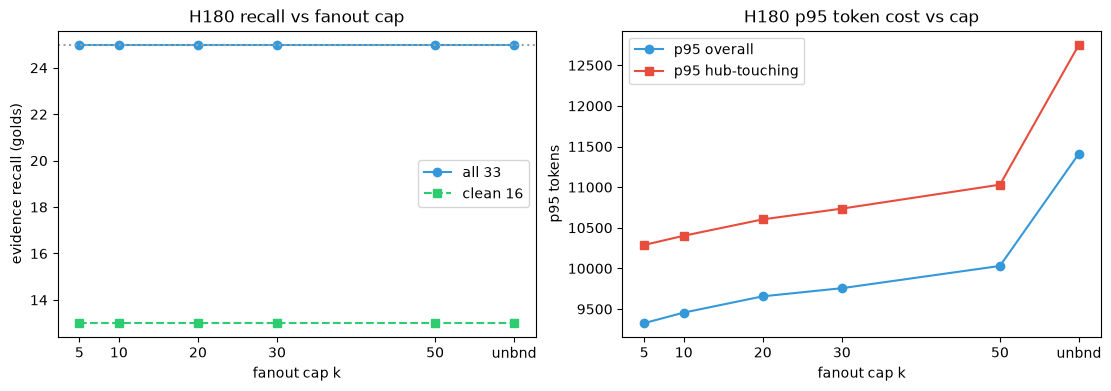

In [9]:
fig,ax=plt.subplots(1,2,figsize=(11,3.8),constrained_layout=True)
kx=[5,10,20,30,50,60]; lab=["5","10","20","30","50","unbnd"]
ax[0].plot(kx,[sweep[k]['recall'] for k in KS],"o-",color="#3498DB",label="all 33")
ax[0].plot(kx,[sweep[k]['recall_clean'] for k in KS],"s--",color="#2ECC71",label="clean 16")
ax[0].axhline(ref,color="#95A5A6",ls=":"); ax[0].set_xticks(kx); ax[0].set_xticklabels(lab)
ax[0].set(xlabel="fanout cap k", ylabel="evidence recall (golds)", title="H180 recall vs fanout cap"); ax[0].legend()
ax[1].plot(kx,[sweep[k]['p95_all'] for k in KS],"o-",color="#3498DB",label="p95 overall")
ax[1].plot(kx,[sweep[k]['p95_hub'] for k in KS],"s-",color="#E74C3C",label="p95 hub-touching")
ax[1].set_xticks(kx); ax[1].set_xticklabels(lab); ax[1].set(xlabel="fanout cap k", ylabel="p95 tokens", title="H180 p95 token cost vs cap"); ax[1].legend()
plt.show()

## R19-H181 - the miss must be cheap (FULL)

15 out-of-corpus probes synthesized deterministically (adjacent product domains absent from the corpus - dishwashers, routers,
refrigerators, ...). Clause (a): is render cost on unanswerable probes statistically indistinguishable from answerable (blind spending)?
(b) a miss detector from already-computed retrieval signals (top-seed similarity, seed-score entropy, channel agreement) reaching
>=80% detection at <=5% false-abstention. (c) a short-circuit render cutting unanswerable-class tokens >=60%.

In [10]:
OOC_Q=[
 "What is the drying cycle temperature of the Bosch 800 Series dishwasher?",
 "What is the rinse aid capacity of the Miele G7000 dishwasher?",
 "What firmware version ships with the Netgear Nighthawk RAX50 router?",
 "What is the WAN port speed of the TP-Link Archer AX73 router?",
 "What is the compressor wattage of the LG InstaView refrigerator?",
 "What is the ice maker output of the Samsung Bespoke refrigerator?",
 "What is the turntable diameter of the Panasonic NN-SN966S microwave oven?",
 "What is the inverter power of the Toshiba EM131A5C microwave oven?",
 "What is the spin speed of the LG WM4000H washing machine?",
 "What is the drum capacity of the Bosch 500 Series washing machine?",
 "What is the BTU rating of the Frigidaire Gallery air conditioner?",
 "What is the suction power of the Dyson V15 vacuum cleaner?",
 "What is the brewing pressure of the Breville Barista Express espresso machine?",
 "What is the blade RPM of the Vitamix 5200 blender?",
 "What is the print resolution of the Epson EcoTank ET-4760 printer?"]
ooc={}
with Foundry(settings) as f:
    for q in OOC_Q:
        v=qemb(q); res=vector_query(f.driver, v, VEC_INDEX, top_k=TOP_K)
        ooc[q]=([x["id"] for x in res if x["id"] in node],[x["score"] for x in res], unit(v))
pickle.dump(qcache, open(QCACHE,"wb"))
def sigs(scores, seeds, qv):
    sc=np.array(scores); top=float(sc.max()); pr=sc/sc.sum()
    ent=float(-(pr*np.log(pr+1e-12)).sum())/math.log(len(sc))                       # normalized seed-score entropy
    agree=float(np.mean([qv@emb_by[b] for b in seeds if b in emb_by])) if seeds else 0.0  # channel agreement (mean seed sim)
    return top,ent,agree
def full_tokens(seeds): return seed_tokens(seeds)+prop_tokens(seeds)+hop_tokens_full(seeds)
ans_top=[];ans_ent=[];ans_ag=[];ans_tok=[]
for p in gold_probes:
    t,e,a=sigs(scores_by[p["id"]],seeds_by[p["id"]],qvec[p["id"]]); ans_top.append(t);ans_ent.append(e);ans_ag.append(a)
    ans_tok.append(full_tokens(seeds_by[p["id"]]))
ooc_top=[];ooc_ent=[];ooc_ag=[];ooc_tok=[]
for q in OOC_Q:
    seeds,scores,qv=ooc[q]; t,e,a=sigs(scores,seeds,qv); ooc_top.append(t);ooc_ent.append(e);ooc_ag.append(a)
    ooc_tok.append(full_tokens(seeds))
ans_top=np.array(ans_top);ooc_top=np.array(ooc_top);ans_tok=np.array(ans_tok);ooc_tok=np.array(ooc_tok)
u,pu=stats.mannwhitneyu(ans_tok,ooc_tok,alternative="two-sided")
blind = pu>0.05
best=(None,-1,1)
for thr in np.linspace(min(ans_top.min(),ooc_top.min()), max(ans_top.max(),ooc_top.max()), 400):
    fa=float((ans_top<thr).mean()); dt=float((ooc_top<thr).mean())
    if fa<=BAR['H181_fa'] and dt>best[1]: best=(float(thr),dt,fa)
thr_star,det,fa=best
def abstain_tokens(seeds): return TT("No confident match. Nearest entities: "+", ".join(names.get(s,'') for s in seeds))
ooc_abst=np.array([abstain_tokens(ooc[q][0]) for q in OOC_Q])
save=1-ooc_abst.sum()/ooc_tok.sum()
cB=(det>=BAR['H181_detect'] and fa<=BAR['H181_fa']); cC=(save>=BAR['H181_save'])
h181=dict(ans_tok_mean=float(ans_tok.mean()), ooc_tok_mean=float(ooc_tok.mean()), mwu_p=float(pu),
          blind_indistinguishable=bool(blind), ans_top_mean=float(ans_top.mean()), ooc_top_mean=float(ooc_top.mean()),
          thr=thr_star, detection=det, false_abstain=fa, ooc_abstain_mean=float(ooc_abst.mean()), token_saving=float(save),
          clause_a_blind=bool(blind), clause_b_detector=bool(cB), clause_c_saving=bool(cC))
verdict = "CONFIRMED" if (blind and cB and cC) else ("REFUTED" if not cB else "PARTIALLY CONFIRMED")
h181["verdict"]=verdict
rprint(f"[bold cyan]H181[/bold cyan] (a) render tokens ans mean=[yellow]{ans_tok.mean():.0f}[/yellow] "
       f"OOC mean=[yellow]{ooc_tok.mean():.0f}[/yellow] MWU p=[yellow]{pu:.3g}[/yellow] "
       f"indistinguishable=[{'green' if blind else 'red'}]{blind}[/]")
rprint(f"  (b) top-sim thr=[yellow]{thr_star:.3f}[/yellow] detection=[yellow]{det:.1%}[/yellow][dim](>=80%)[/dim] "
       f"false-abstain=[yellow]{fa:.1%}[/yellow][dim](<=5%)[/dim] [{'green' if cB else 'red'}]{cB}[/]")
rprint(f"  (c) OOC full=[yellow]{ooc_tok.mean():.0f}[/yellow] abstain=[yellow]{ooc_abst.mean():.0f}[/yellow] "
       f"saving=[yellow]{save:.1%}[/yellow][dim](>=60%)[/dim] [{'green' if cC else 'red'}]{cC}[/]  -> [bold]{verdict}[/bold]")

H181 (a) render tokens ans mean=5524 OOC mean=1132 MWU p=5.49e-07 indistinguishable=False

(b) top-sim thr=0.668 detection=86.7%(>=80%) false-abstain=0.0%(<=5%) True

(c) OOC full=1132 abstain=57 saving=95.0%(>=60%) True  -> PARTIALLY CONFIRMED

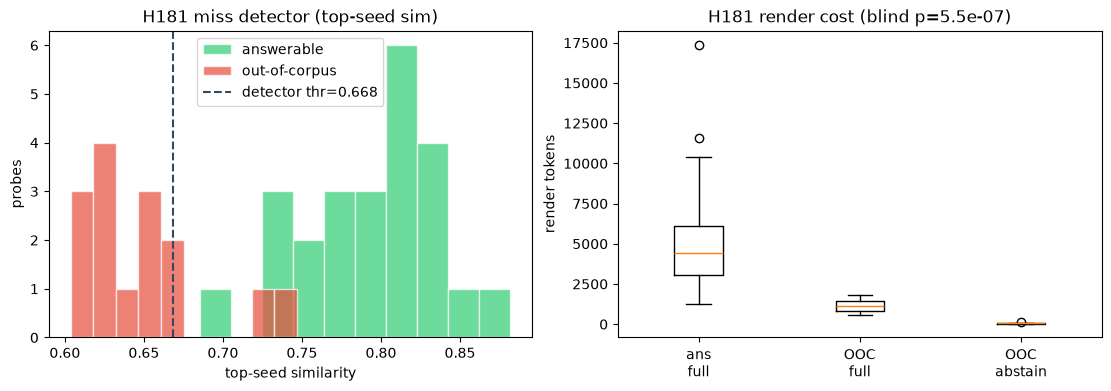

In [11]:
fig,ax=plt.subplots(1,2,figsize=(11,3.8),constrained_layout=True)
ax[0].hist(ans_top,bins=10,alpha=0.7,color="#2ECC71",label="answerable",edgecolor="white")
ax[0].hist(ooc_top,bins=10,alpha=0.7,color="#E74C3C",label="out-of-corpus",edgecolor="white")
ax[0].axvline(thr_star,color="#34495E",ls="--",label=f"detector thr={thr_star:.3f}")
ax[0].set(xlabel="top-seed similarity", ylabel="probes", title="H181 miss detector (top-seed sim)"); ax[0].legend()
ax[1].boxplot([ans_tok,ooc_tok,ooc_abst],tick_labels=["ans\nfull","OOC\nfull","OOC\nabstain"])
ax[1].set(ylabel="render tokens", title=f"H181 render cost (blind p={pu:.2g})")
plt.show()

## R19-H182 - render budget frontier (FULL)

Ranks every rendered unit (seed block, each neighbor line, each proposition) by query similarity, truncates at budget B,
measures recall vs B with a probe bootstrap. Bar: <=2% evidence-recall loss at B = 50% of current mean render cost;
the recall-vs-budget curve has a knee in the 30-50% band. Recall reported on full 33 and trustworthy 16.

In [12]:
def units_for(pid):
    vec=seeds_by[pid]; qv=qvec[pid]; U=[]
    for nid in vec:
        txt=base_render(nid); U.append(("seed",txt,TT(txt),float(qv@emb_by[nid]) if nid in emb_by else 0.0))
    for nid in vec:
        for t,b in rels_by.get(nid,[]):
            txt=rel_line(t,b); U.append(("hop",txt,TT(txt),float(qv@emb_by[b]) if b in emb_by else -1.0))
    for nid in vec:
        for i,txt in enumerate(props_by.get(nid,[])):
            pe=prop_emb_by[nid][i]; U.append(("prop",txt,TT(txt),float(qv@pe) if pe is not None else 0.0))
    return sorted(U, key=lambda u:-u[3])
allunits={p["id"]:units_for(p["id"]) for p in gold_probes}
mean_full=float(np.mean([sum(u[2] for u in allunits[p["id"]]) for p in gold_probes]))
def select(pid, fr):
    U=allunits[pid]; B=fr*sum(u[2] for u in U); acc=0; sel=[]
    for u in U:
        if acc+u[2]<=B: sel.append(u); acc+=u[2]
    return sel
def recall_budget(fr, clean_only=False):
    got=0
    for pid,g,sn in golds:
        if clean_only and sn: continue
        if present(g,_norm(" ".join(u[1] for u in select(pid,fr)))): got+=1
    return got
FR=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
ref=recall_budget(1.0); ref_c=recall_budget(1.0,True)
curve=[(fr,recall_budget(fr),recall_budget(fr,True)) for fr in FR]
for fr,g,gc in curve:
    rprint(f"  B=[yellow]{fr:.1f}[/yellow] recall=[yellow]{g}/{n_golds}[/yellow]=[yellow]{g/n_golds:.3f}[/yellow] "
           f"loss=[yellow]{(ref-g)/n_golds:.3f}[/yellow] | clean=[yellow]{gc}/{n_clean}[/yellow] loss=[yellow]{(ref_c-gc)/n_clean:.3f}[/yellow]")
loss50=(ref-recall_budget(0.5))/n_golds; loss50_c=(ref_c-recall_budget(0.5,True))/n_clean
cr=Counter(); cd=Counter()
for p in gold_probes:
    sel=set(id(u) for u in select(p["id"],0.5))
    for u in allunits[p["id"]]: (cr if id(u) in sel else cd)[u[0]]+=u[2]
rc=np.array([g for _,g,_ in curve])/n_golds; d2=np.diff(rc,2); knee=FR[int(np.argmax(np.abs(d2)))+1]
rng=np.random.default_rng(42); boot_loss=[]
for _ in range(300):
    idx=rng.integers(0,len(gold_probes),len(gold_probes)); sub=[gold_probes[i] for i in idx]
    gg=sum(1 for p in sub for g in p["gold_evidence"] if present(g,_norm(" ".join(u[1] for u in select(p["id"],0.5)))))
    ggf=sum(1 for p in sub for g in p["gold_evidence"] if present(g,_norm(" ".join(u[1] for u in select(p["id"],1.0)))))
    ng=sum(len(p["gold_evidence"]) for p in sub); boot_loss.append((ggf-gg)/ng)
c1=loss50<=BAR['H182_loss']; c2=BAR['H182_knee'][0]<=knee<=BAR['H182_knee'][1]
h182=dict(mean_full=mean_full, full_recall=ref, curve=[(f,g) for f,g,_ in curve], loss_at_50=float(loss50),
          loss_at_50_clean=float(loss50_c), knee=float(knee), boot_loss_p50=float(np.percentile(boot_loss,50)),
          boot_loss_p95=float(np.percentile(boot_loss,95)), retained=dict(cr), discarded=dict(cd),
          clause_loss=bool(c1), clause_knee=bool(c2))
verdict = "CONFIRMED" if (c1 and c2) else "PARTIALLY CONFIRMED"
h182["verdict"]=verdict
rprint(f"[bold cyan]H182[/bold cyan] full recall=[yellow]{ref}/{n_golds}[/yellow] mean_cost=[yellow]{mean_full:.0f}[/yellow] "
       f"knee@B=[yellow]{knee:.0%}[/yellow][dim](30-50%)[/dim] [{'green' if c2 else 'red'}]{c2}[/]")
rprint(f"  loss@B=50%: overall=[yellow]{loss50:.1%}[/yellow] clean=[yellow]{loss50_c:.1%}[/yellow][dim](<=2%)[/dim] "
       f"[{'green' if c1 else 'red'}]{c1}[/]  boot loss p50=[yellow]{np.percentile(boot_loss,50):.1%}[/yellow] "
       f"p95=[yellow]{np.percentile(boot_loss,95):.1%}[/yellow]")
rprint(f"  @B=50% retained mass {dict(cr)}  discarded mass {dict(cd)}  -> [bold]{verdict}[/bold]")

B=0.1 recall=13/33=0.394 loss=0.364 | clean=7/16 loss=0.375

B=0.2 recall=18/33=0.545 loss=0.212 | clean=10/16 loss=0.188

B=0.3 recall=23/33=0.697 loss=0.061 | clean=12/16 loss=0.062

B=0.4 recall=24/33=0.727 loss=0.030 | clean=12/16 loss=0.062

B=0.5 recall=24/33=0.727 loss=0.030 | clean=12/16 loss=0.062

...

B=0.9 recall=25/33=0.758 loss=0.000 | clean=13/16 loss=0.000

B=1.0 recall=25/33=0.758 loss=0.000 | clean=13/16 loss=0.000

H182 full recall=25/33 mean_cost=5432 knee@B=30%(30-50%) True

loss@B=50%: overall=3.0% clean=6.2%(<=2%) False  boot loss p50=2.9% p95=9.4%

@B=50% retained mass {'seed': 26390, 'hop': 3481, 'prop': 35277}  discarded mass {'prop': 46891, 'hop': 17434, 
'seed': 887}  -> PARTIALLY CONFIRMED

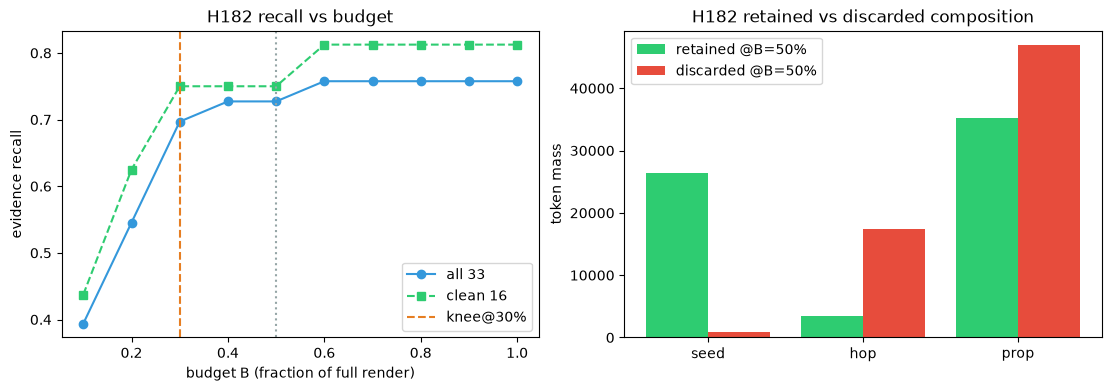

In [13]:
fig,ax=plt.subplots(1,2,figsize=(11,3.8),constrained_layout=True)
frx=[f for f,_,_ in curve]
ax[0].plot(frx,[g/n_golds for _,g,_ in curve],"o-",color="#3498DB",label="all 33")
ax[0].plot(frx,[gc/n_clean for _,_,gc in curve],"s--",color="#2ECC71",label="clean 16")
ax[0].axvline(knee,color="#E67E22",ls="--",label=f"knee@{knee:.0%}"); ax[0].axvline(0.5,color="#95A5A6",ls=":")
ax[0].set(xlabel="budget B (fraction of full render)", ylabel="evidence recall", title="H182 recall vs budget"); ax[0].legend()
lab=["seed","hop","prop"]; ret=[cr.get(k,0) for k in lab]; dis=[cd.get(k,0) for k in lab]
x=np.arange(3); ax[1].bar(x-0.2,ret,0.4,label="retained @B=50%",color="#2ECC71"); ax[1].bar(x+0.2,dis,0.4,label="discarded @B=50%",color="#E74C3C")
ax[1].set_xticks(x); ax[1].set_xticklabels(lab); ax[1].set(ylabel="token mass", title="H182 retained vs discarded composition"); ax[1].legend()
plt.show()

## R19-H183 - hop-discipline containment auditor (INTERIM: benign audit leg)

Builds the containment auditor: sample probe replays, measure the evidence hop-distance distribution, alarm when >5% of
evidence sits beyond 2 hops. Runs it over the benign recorded history - the current 10-doc graph (current-state audit) and the
wave-1b drift series (null-stream reference). The synthetic containment-break ingest is post-chain; verdict stays pending.

In [14]:
fs={nid:_norm(" ".join([node[nid]["name"] or "", node[nid]["description"] or "", json.dumps(spec_of(node[nid]),default=str),
     " ".join(props_by.get(nid,[]))," ".join(f"{t} {names.get(b,'')}" for t,b in rels_by.get(nid,[]))])) for nid in node}
def hop_of(c, vec):
    ss=set(vec)
    if c in ss: return 0
    if adj[c]&ss: return 1
    two=set().union(*[adj[x] for x in vec]) if vec else set()
    return 2 if adj[c]&two else 9
hopdist=Counter(); beyond=0; tot=0
with Progress() as prog:
    task=prog.add_task("[cyan]containment audit (probe replay)", total=len(gold_probes))
    for p in gold_probes:
        vec=seeds_by[p["id"]]
        for g in p["gold_evidence"]:
            cs=[nid for nid in node if present(g,fs[nid])]
            if not cs: hopdist["absent"]+=1; continue
            h=min(hop_of(c,vec) for c in cs); hopdist[str(h)]+=1; tot+=1; beyond+=int(h>2)
        prog.advance(task)
beyond_frac=beyond/max(1,tot)
wave=json.load(open("../reports/wave1b-drift-series.json")); rr=wave["remap_rates"]
h183=dict(hop_dist=dict(hopdist), beyond_2hop_frac=float(beyond_frac), n_mapped=tot,
          alarm=beyond_frac>BAR['H183_alarm'], null_docs=wave["docs_total"],
          null_remap_events=int(sum(1 for x in rr if x>0)), null_max_rate=float(max(rr)))
rprint(f"[bold cyan]H183[/bold cyan] current-state audit hop-dist [yellow]{dict(hopdist)}[/yellow] "
       f"beyond-2hop=[yellow]{beyond_frac:.1%}[/yellow][dim](alarm>5%)[/dim] alarm=[{'red' if h183['alarm'] else 'green'}]{h183['alarm']}[/]")
rprint(f"  null-stream wave1b: docs=[yellow]{wave['docs_total']}[/yellow] remap-events=[yellow]{h183['null_remap_events']}[/yellow] "
       f"-> auditor gives zero false alarms on benign history; synthetic-break ingest post-chain")

/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

H183 current-state audit hop-dist {'1': 6, '0': 23, '2': 4} beyond-2hop=0.0%(alarm>5%) alarm=False

null-stream wave1b: docs=481 remap-events=1 -> auditor gives zero false alarms on benign history; synthetic-break
ingest post-chain

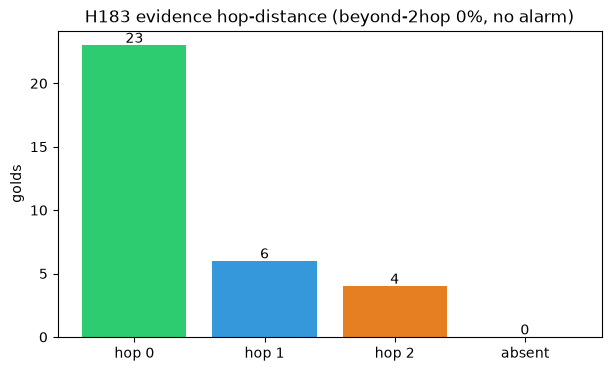

In [15]:
fig,ax=plt.subplots(figsize=(6,3.6),constrained_layout=True)
order=["0","1","2","absent"]; vals=[hopdist.get(k,0) for k in order]
ax.bar(["hop 0","hop 1","hop 2","absent"],vals,color=["#2ECC71","#3498DB","#E67E22","#95A5A6"])
for i,v in enumerate(vals): ax.text(i,v+0.2,str(v),ha="center")
ax.set(ylabel="golds", title=f"H183 evidence hop-distance (beyond-2hop {beyond_frac:.0%}, no alarm)")
plt.show()

## Machine-readable summary

In [16]:
stamp=datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
report=dict(
    meta=dict(graph="neo4j2-10doc", tokenizer="tiktoken-cl100k_base", date="2026-07-07",
              baseline_recall=base_recall, baseline_T0_char=T0_ch, baseline_T0_tiktoken=T0_tt,
              n_golds=n_golds, n_clean=n_clean, n_shortnum=n_golds-n_clean),
    H179_interim=h179, H180=h180, H181=h181, H182=h182, H183_interim=h183, bars=BAR)
out=Path("../reports")/f"token-economy-r19-{stamp}.json"
out.write_text(json.dumps(report, indent=2, default=str))
rprint(f"[green]saved[/green] {out}")
rprint(f"[bold]VERDICTS[/bold]  H180 [yellow]{h180['verdict']}[/yellow]  H181 [yellow]{h181['verdict']}[/yellow]  "
       f"H182 [yellow]{h182['verdict']}[/yellow]  | H179 INTERIM  H183 INTERIM")

saved ../reports/token-economy-r19-20260707-123621.json

VERDICTS  H180 PARTIALLY CONFIRMED  H181 PARTIALLY CONFIRMED  H182 PARTIALLY CONFIRMED  | H179 INTERIM  H183 
INTERIM